# RSA model implementation

This is an implementation of a basic RSA model, which you can use to test how different parameter values affect the speaker's interpretation.

## 1. Model definition

First, we define the model. **The model is already implemented and working so you don't need to do anything at this step.**

*   Possible referents (o): person with a beret, person with a beret and a scarf.
*   Possible messages (m): "beret", "scarf".

### Literal listener
The literal listener inteprets the message based on its literal meaning $[[m]](o)$ and the prior probability of referents $P(o)$:

$L_{0}(o|m) \propto [[m]](o) \cdot P(o)$

### Pragmatic speaker
The pragmatic speaker chooses their utterances in proportion to their utility $U$, which maximizes the probability of correct interpretation by $L_{0}$ while minimizing utterance cost:

$S_{1}(m|o) \propto exp(\alpha \cdot U(m;o))$

$U = log L_{0}(o|m) - Cost(m)$

## Pragmatic listener
Finally, the pragmatic listener interprets the utterance by reasoning about the speaker $S_{1}$ and the prior probability of referents $P(o)$:

$L_{1}(o|m) \propto S_{1}(m|o) \cdot P(o)$








In [36]:
import numpy as np
import matplotlib.pyplot as plt

In [37]:
'''
simple RSA model
'''
class RSAExample:
	def __init__(self, alpha, priors, cost_function):
		self.objects = ["beret","beret_scarf"]
		self.messages = ["beret","scarf"]
		self.alpha = alpha
		self.priors = priors
		self.cost_function = cost_function

	'''
	function to normalize an array by dividing each row by its sum
	to obtain a probability distribution
	'''
	def normalize(self,arr):
		return arr / arr.sum(axis=1)[:, np.newaxis]

	'''
	[[m]](o) -- literal meaning of utterances
	dimensions: 2 objects x 2 messages
	'''
	def L0_truth_table(self):
		t = np.array([
				 [1,1],
				 [0,1]
				 ])

		return t

	'''
	literal listener L0(o|m)
	matrix dimensions: 3 messages x 2 objects
	'''
	def L0(self):
		#compute [[m]](o): literal meaning
		literal_meaning = self.L0_truth_table()

		#P(o) -- create a matrix of priors by repeating the priors array for each row
		priors = np.tile(np.array(self.priors), (2, 1))

		#multiply the two of L0 terms together
		unnorm  =  literal_meaning * priors

		#normalize to obtain a probability distribution
		norm = self.normalize(unnorm)

		return norm

	'''
	pragmatic speaker S1(m|o)
	matrix dimensions: 2 objects x 2 messages
	'''
	def S1(self):
		#compute the costs for each expression in self.messages
		costs = self.cost_function()

		#utility without costs
		raw_utility = np.log(self.L0().T)

		#Cost(m) -- reshape to obtain correct dimensions for matrix multiplication
		costs = np.repeat(self.cost_function(),2).reshape((2,2)).T

		#compute utility by subtracting costs from informativity
		utility = np.subtract(raw_utility,costs)

		#compute S1(m|o) by taking the exponent of utility times the temperature parameter alpha
		unnorm = np.exp(self.alpha*utility)

		#normalize to obtain a probability distribution
		norm = self.normalize(unnorm)

		return norm

	'''
	literal listener L1(o|m)
	matrix dimensions: 2 messages x 2 objects
	'''
	def L1(self):
		#S1(m|o)
		S1 = self.S1()
		#P(o) -- create a matrix of priors by repeating the priors array for each row
		priors = np.tile(np.array(self.priors), (2, 1))

		#multiply S1(m|o) (transformed, since we need a distribution over objects, not over messages) and P(o) together
		unnorm = S1.T * priors

		#normalize to obtain a probability distribution
		norm = self.normalize(unnorm)

		return norm

	'''
	PLOTTING

	simple barplots
	'''
	def plot_L0(self):
		# Get the L0 values for the two messages (the first row of the L0 matrix corresponds to "beret" and the second row corresponds to "scarf")
		L0_vals_beret = self.L0()[0, :]
		L0_vals_scarf = self.L0()[1, :]

		# Create a figure with two subplots side by side
		fig, axes = plt.subplots(1, 2, figsize=(10, 5))

		# Plot for "beret"
		axes[0].bar(self.objects, L0_vals_beret)
		axes[0].set_title('L0 probability for each referent when hearing "beret"')
		axes[0].set_xlabel('referent')
		axes[0].set_ylabel('probability')

		# Plot for "scarf"
		axes[1].bar(self.objects, L0_vals_scarf)
		axes[1].set_title('L0 probability for each referent when hearing "scarf"')
		axes[1].set_xlabel('referent')
		axes[1].set_ylabel('probability')

		plt.tight_layout()
		plt.show()

	def plot_S1(self):
		# Get the S1 values for the two referents (the first row corresponds to the person wearing a beret and no scarf and the second row corresponds to the person wearing a scarf)
		S1_vals_beret = self.S1()[0,:]
		S1_vals_beret_scarf = self.S1()[1,:]

		# Create a figure with two subplots side by side
		fig, axes = plt.subplots(1, 2, figsize=(10, 5))

		# Plot for the person with a beret and no scarf
		axes[0].bar(self.messages, S1_vals_beret)
		axes[0].set_title('S1 probability of using each message\n to refer to the person with a beret and no scarf')
		axes[0].set_xlabel('message')
		axes[0].set_ylabel('probability')

		# Plot for the person with a scarf
		axes[1].bar(self.messages, S1_vals_beret_scarf)
		axes[1].set_title('S1 probability of using each message\n to refer to the person with a scarf')
		axes[1].set_xlabel('message')
		axes[1].set_ylabel('probability')

		plt.tight_layout()
		plt.show()

	def plot_L1(self):
		# Get the L1 values for the two messages (the first row of the L0 matrix corresponds to "beret" and the second row corresponds to "scarf")
		L1_vals_beret = self.L1()[0, :]
		L1_vals_scarf = self.L1()[1, :]

		# Create a figure with two subplots side by side
		fig, axes = plt.subplots(1, 2, figsize=(10, 5))

		# Plot for "beret"
		axes[0].bar(self.objects, L1_vals_beret)
		axes[0].set_title('L1 probability for each referent when hearing "beret"')
		axes[0].set_xlabel('referent')
		axes[0].set_ylabel('probability')

		# Plot for "scarf"
		axes[1].bar(self.objects, L1_vals_scarf)
		axes[1].set_title('L1 probability for each referent when hearing "scarf"')
		axes[1].set_xlabel('referent')
		axes[1].set_ylabel('probability')

		plt.tight_layout()
		plt.show()


## 2. Setting model parameters

Here, we set the model parameters and run the model.


## Priors $P_{o}$

Here, we set the prior probability that each of the referents — the person with a beret and the person with a beret and a scarf — will be referred to.

Since $P(o)$ is a probability distribution, the priors need to sum up to 1.

In [38]:
'''
You can substitute different priors in here.
These are the priors for the referent array [person with a beret, person with a beret and a scarf] (in that order).
Remember that since P(o) is a probability distribution, the priors need to sum up to 1.

NOTE: Please don't set any of the priors to 0 since that may lead to issues in the computation. You can set it to a very small value, like 0.01, instead.
'''
priors = [.5, .5]

## Speaker's temperature parameter $\alpha$

You can substitute different values for the $\alpha$ parameter here. $\alpha$ controls the extent to which the speaker maximizes their utility. A higher $\alpha$ makes differences in probabilities more extreme.

We generally assume that $1 \leq \alpha \leq \infty$.
(However, if you are curious, you are welcome to try setting $\alpha$ to 0 to see what happens).


In [39]:
alpha = 1

## Message cost $C(m)$

Here, we define a function which determines the cost of the possible messages (e.g., word length, frequency). The more costly messages are, the less likely they are to be produced.

The cost function is *not* a probability distibution, so the costs don't need to sum to 1. Message cost should be *non-negative* (i.e., at least 0)

The cost function takes in the array ["beret", "scarf"] and outputs the costs for each of those messages as a vector (e.g, [0,0]). It's up to you whether you want to modify the output vector directly or write a function that uses the referents in some way.

In [58]:
'''
The cost function should output the costs for the message array ["beret","scarf"] (in that order).
The cost function below assigns zero cost to each of the elements.
'''
def cost_function():
	referents = ["beret","scarf"]
	return [1, 100]

## 3. Plotting model predictions

## Initializing the model

First, initialize the model with the parameters set above by running the code block below.

In [59]:
'''
initialize the model
'''
example = RSAExample(priors = priors, alpha = alpha, cost_function = cost_function)

## Plotting $L_{0}$

Below, we compute and plot the literal listener's interpretations upon hearing "beret" (left) and "scarf" (right).

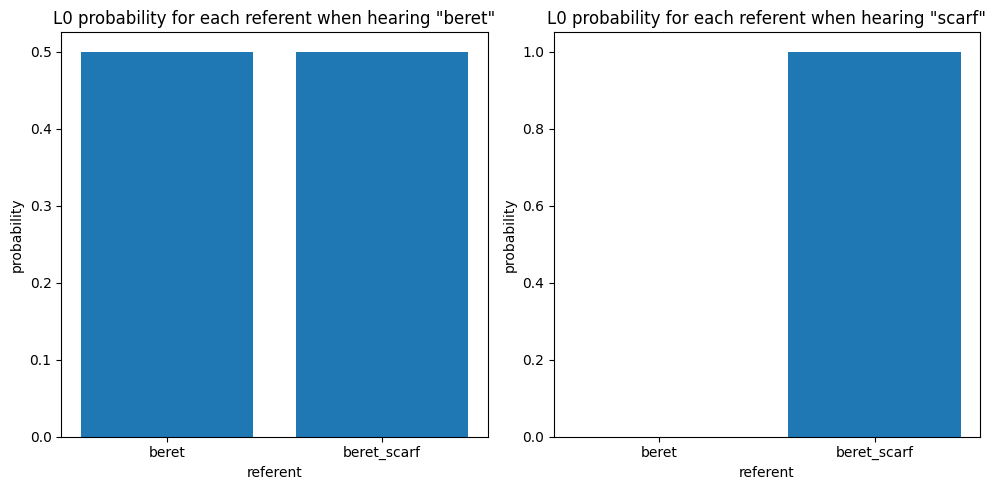

In [42]:
'''
Compute and plot L0(o|"beret") and L0(o|"scarf")
'''
example.plot_L0()

## Plotting $S_{1}$

Below, we compute and plot the pragmatic speaker's probability of using each message to refer to the person with a beret and no scarf (left) and to the person with a scarf (right).

/tmp/ipykernel_630721/2092409624.py:59: RuntimeWarning: divide by zero encountered in log
  raw_utility = np.log(self.L0().T)


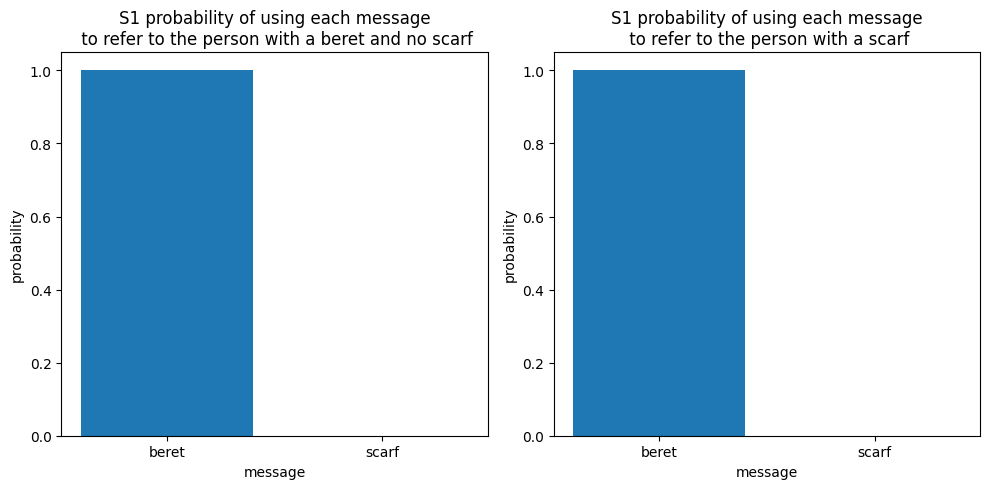

In [47]:
'''
Compute and plot S1(m|beret and no scarf) and S1(m|beret and scarf)
'''
example.plot_S1()

## Plotting $L_{1}$

Below, we compute and plot the pragmatic listener's interpretations upon hearing "beret" (left) and "scarf" (right).

/tmp/ipykernel_630721/2092409624.py:59: RuntimeWarning: divide by zero encountered in log
  raw_utility = np.log(self.L0().T)


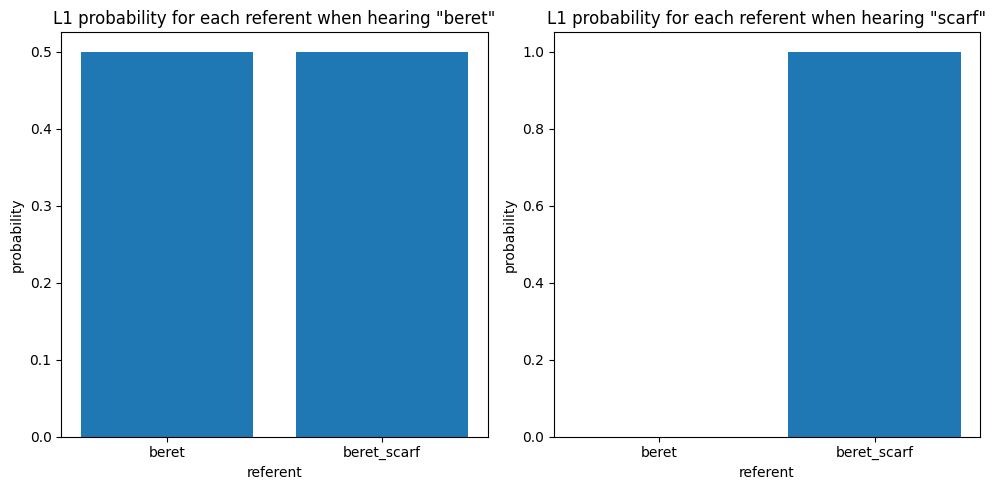

In [60]:
'''
Compute and plot L1(o|"beret") and L1(o|"scarf")
'''
example.plot_L1()